# Baseline PortScan Detection Model

This notebook builds a baseline machine-learning model for distinguishing
BENIGN network traffic from PortScan activity using the cleaned CICIDS2017
subset prepared in the previous notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
data_path = Path("../data/processed/portscan_clean.csv")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print(df["Label"].value_counts())

Dataset shape: (213777, 79)
Label
BENIGN      123083
PortScan     90694
Name: count, dtype: int64


In [3]:
X = df.drop(columns=["Label"])

y = df["Label"].map({
    "BENIGN": 0,
    "PortScan": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (213777, 78)
y shape: (213777,)

Target distribution:
Label
0    123083
1     90694
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 171021
Testing samples: 42756


In [5]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training class distribution:
Label
0    0.5758
1    0.4242
Name: proportion, dtype: float64

Testing class distribution:
Label
0    0.5758
1    0.4242
Name: proportion, dtype: float64


In [6]:
# Build the baseline Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [7]:
# Make predictions on the test set

y_pred = rf_model.predict(X_test)

print("Prediction completed!")
print("Number of predictions:", len(y_pred))

Prediction completed!
Number of predictions: 42756


In [8]:
# Evaluate the baseline model

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Baseline Random Forest Results")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Baseline Random Forest Results
--------------------------------
Accuracy : 0.9999
Precision: 1.0000
Recall   : 0.9998
F1-score : 0.9999


In [9]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[24617     0]
 [    4 18135]]


In [10]:
# Feature importance

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15))

Top 15 Most Important Features:
Flow IAT Max                   0.067407
Subflow Fwd Bytes              0.065764
Fwd Packet Length Mean         0.062351
Bwd Packets/s                  0.061594
Average Packet Size            0.058808
Total Length of Fwd Packets    0.053091
Fwd Packet Length Max          0.050691
PSH Flag Count                 0.048647
Packet Length Mean             0.048397
Packet Length Std              0.045603
Flow Duration                  0.044349
Avg Fwd Segment Size           0.040913
Subflow Fwd Packets            0.037436
Max Packet Length              0.032046
ACK Flag Count                 0.022461
dtype: float64


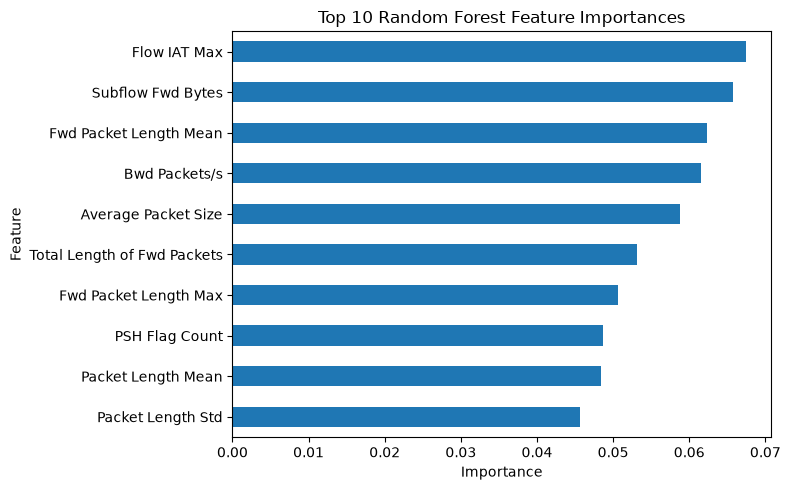

In [11]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
top_features.sort_values().plot(kind="barh")

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [12]:
# Check for exact duplicate samples between train and test sets

train_rows = set(map(tuple, X_train.values))
test_rows = set(map(tuple, X_test.values))

overlap = train_rows.intersection(test_rows)

print("Exact duplicate samples between train and test:", len(overlap))

Exact duplicate samples between train and test: 0


In [13]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("F1 scores for 5 folds:")
print(cv_scores)

print("\nMean F1-score:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

F1 scores for 5 folds:
[0.99958638 1.         1.         1.         0.99826039]

Mean F1-score: 0.9995693534783789
Standard deviation: 0.0006738020818634879


## Baseline Model Summary

A Random Forest classifier was trained as the baseline model for distinguishing
BENIGN traffic from PortScan attacks.

The model achieved very high performance on the held-out test set, with an
F1-score of approximately 0.9999. Only four PortScan samples were incorrectly
classified as BENIGN.

Feature-importance analysis showed that the model relied on multiple network-flow
characteristics rather than a single dominant feature.

No exact duplicate samples were found between the training and test sets.
Furthermore, 5-fold cross-validation produced a mean F1-score of approximately
0.9996 with very low variation across folds.

These results indicate strong and stable baseline performance on the current
PortScan dataset. Further evaluation on more challenging data splits is required
to assess generalization to unseen network scenarios.